In [1]:
import pandas as pd
import os
import scanpy as sc
import anndata as ad
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import shutil
import muon as mu
import scirpy as ir
import anndata
from tqdm import tqdm
from scipy.stats import entropy
import matplotlib.patches as mpatches

import rpy2
import rpy2.robjects as ro
from rpy2.robjects.packages import importr
from rpy2.robjects import pandas2ri

from rpy2.robjects.conversion import localconverter

%load_ext rpy2.ipython

/home/jupyter/mambaforge/envs/python38/lib/python3.8/site-packages/umap/distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/home/jupyter/mambaforge/envs/python38/lib/python3.8/site-packages/umap/distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/home/jupyter/mambaforge/envs/python38/lib/python3.8/site-packag

In [2]:
adata = sc.read_h5ad('/home/jupyter/data/ge_korea/results/tcr_analysis/mvtcr_adata.h5ad')

In [3]:
gene_sig = pd.read_excel('/home/jupyter/data/ge_korea/results/spectra/spectra_supplementary_tables.xlsx',sheet_name='Supplementary_Table_3')

In [5]:
%%R
library(UCell)
library(readxl)
gene_sig = read_xlsx('/home/jupyter/data/ge_korea/results/spectra/spectra_supplementary_tables.xlsx', sheet = 3)
spectra_TR_sig = gene_sig$GENE_ID

In [8]:
%%R
# converting .h5ad object from scanpy to seurat object for quick and easy exploration of data
library("schard")
library("Seurat")
srt = schard::h5ad2seurat('/home/jupyter/data/ge_korea/results/tcr_analysis/mvtcr_adata.h5ad')

In [11]:
%%R
# checking that it works
print(dim(srt))
print(head(srt@meta.data))
print(unique(srt@meta.data$tissue))
print(table(srt$patient, srt$timepoint))

[1] 36601 66816
                        orig.ident nCount_RNA nFeature_RNA
E30_F1_AAACCTGTCTCGGACG        E30       4482         1527
E30_F1_AAACGGGCAACCGCCA        E30       3101         1362
E30_F1_AAACGGGCACTTCGAA        E30       2610         1352
E30_F1_AAAGATGCAAGTTAAG        E30       2655         1232
E30_F1_AAAGATGGTACCGGCT        E30       2402         1080
E30_F1_AAAGATGTCCACGACG        E30       2228         1089
                                   sample_index sample_x patient timepoint
E30_F1_AAACCTGTCTCGGACG E30_F1_AAACCTGTCTCGGACG   E30_F1     E30        F1
E30_F1_AAACGGGCAACCGCCA E30_F1_AAACGGGCAACCGCCA   E30_F1     E30        F1
E30_F1_AAACGGGCACTTCGAA E30_F1_AAACGGGCACTTCGAA   E30_F1     E30        F1
E30_F1_AAAGATGCAAGTTAAG E30_F1_AAAGATGCAAGTTAAG   E30_F1     E30        F1
E30_F1_AAAGATGGTACCGGCT E30_F1_AAAGATGGTACCGGCT   E30_F1     E30        F1
E30_F1_AAAGATGTCCACGACG E30_F1_AAAGATGTCCACGACG   E30_F1     E30        F1
                        normal batch is_cell h

In [24]:
%%R
tr_sigs = list("spectra_TR" = spectra_TR_sig)
srt <- AddModuleScore_UCell(srt, features = tr_sigs)
scored_metadata = cbind(srt@meta.data[,c("spectra_TR_UCell")],rownames(srt@meta.data))
write.csv(scored_metadata, file = "/home/jupyter/data/ge_korea/results/tcr_analysis/spectra_tr/tcells_UCell_TRsig_scored.csv")

                        imputed to exp=0:
* STAT5


In [23]:
%%R
cbind(srt@meta.data[,c("spectra_TR_UCell")],rownames(srt@meta.data))

     [,1]                 [,2]                     
[1,] "0.12358"            "E30_F1_AAACCTGTCTCGGACG"
[2,] "0.0405066666666667" "E30_F1_AAACGGGCAACCGCCA"
[3,] "0.119406666666667"  "E30_F1_AAACGGGCACTTCGAA"
[4,] "0.05142"            "E30_F1_AAAGATGCAAGTTAAG"
[5,] "0.12472"            "E30_F1_AAAGATGGTACCGGCT"
[6,] "0.12232"            "E30_F1_AAAGATGTCCACGACG"


In [ ]:
sc.tl.score_genes(adata,tr_gene_list,score_name='spectra_tr_score')

In [20]:
adata = sc.read_h5ad('/home/jupyter/data/ge_korea/results/ge_korea_tnk_annotation.h5ad')

In [21]:
sc.tl.score_genes(adata,tr_gene_list,score_name='spectra_tr_score')

/home/jupyter/mambaforge/envs/python38/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


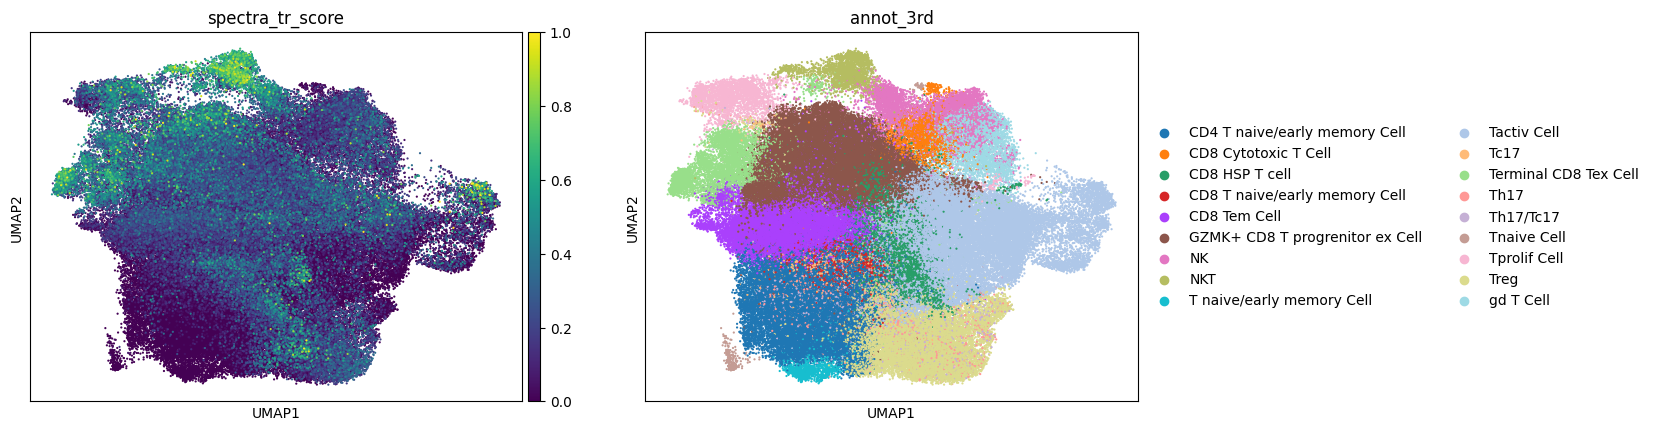

In [25]:
%matplotlib inline
sc.pl.umap(adata, color=['spectra_tr_score','annot_3rd'],neighbors_key='log1p_norm_pca',size=10,
          layer='log1p_norm',ncols=2,vmin=0,vmax=1)
           #save='umap_leiden.pdf')